In [ ]:
#Phùng Trí Quân

In [4]:
# IMPORT THƯ VIỆN CHUNG
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import BatchNormalization

# MOUNT GOOGLE DRIVE
from google.colab import drive
drive.mount('/content/drive')

# CẤU HÌNH CHUNG
DATA_DIR = "/content/drive/MyDrive/datadoan/plant-health"
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
EPOCHS = 50
VAL_SPLIT = 0.2


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Found 566 images belonging to 2 classes.
Found 141 images belonging to 2 classes.
Số lớp: 2


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 127,682 (498.76 KB)

 Trainable params: 127,234 (497.01 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 126s 3s/step - accuracy: 0.6768 - loss: 0.5915 - val_accuracy: 0.4397 - val_loss: 0.6954 - learning_rate: 3.0000e-04
Epoch 2/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 119s 3s/step - accuracy: 0.8003 - loss: 0.4065 - val_accuracy: 0.4610 - val_loss: 0.7267 - learning_rate: 3.0000e-04
Epoch 3/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 119s 3s/step - accuracy: 0.8325 - loss: 0.3640 - val_accuracy: 0.4610 - val_loss: 0.7470 - learning_rate: 3.0000e-04
Epoch 4/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 119s 3s/step - accuracy: 0.8074 - loss: 0.4139 - val_accuracy: 0.4610 - val_loss: 0.7496 - learning_rate: 3.0000e-04
Epoch 5/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 122s 3s/step - accuracy: 0.8311 - loss: 0.3595 - val_accuracy: 0.5248 - val_loss: 0.6966 - learning_rate: 3.0000e-04
Epoch 6/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 120s 3s/step - accuracy: 0.8543 - loss: 0.3276 - val_accuracy: 0.6099 - val_loss: 0.6718 - learning_rate: 9.0000e-05
Epoch 7/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 141s 3s/step - accuracy: 0.8566 

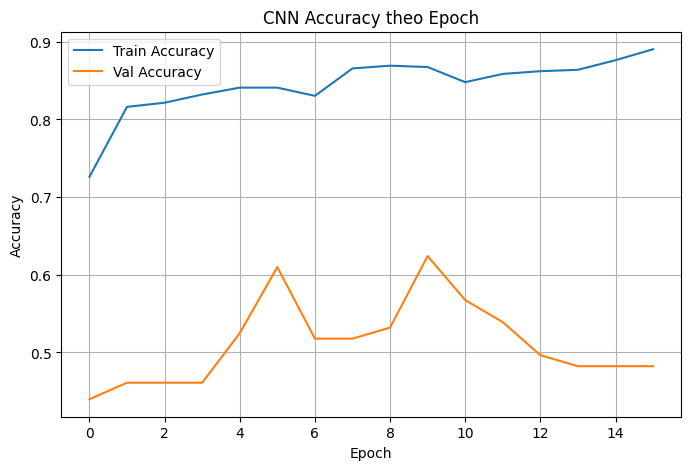

In [ ]:

#  CNN THUẦN

# 1.TIỀN XỬ LÝ 
train_datagen = ImageDataGenerator(
    rescale=1./255,                 # Chuẩn hóa pixel ảnh từ [0,255] → [0,1]
    rotation_range=10,              # Xoay ảnh ngẫu nhiên trong khoảng ±10 độ
    width_shift_range=0.05,         # Dịch ảnh theo chiều ngang tối đa 5%
    height_shift_range=0.05,        # Dịch ảnh theo chiều dọc tối đa 5%
    zoom_range=0.05,                # Phóng to / thu nhỏ ảnh tối đa 5%
    horizontal_flip=True,           # Lật ngang ảnh ngẫu nhiên
    validation_split=VAL_SPLIT      # Chia dữ liệu thành train và validation
)

# Generator cho validation 
val_datagen = ImageDataGenerator(
    rescale=1./255,                 # Chỉ chuẩn hóa ảnh
    validation_split=VAL_SPLIT      # Dùng cùng tỉ lệ chia dữ liệu
)

# 2. TẠO DỮ LIỆU TRAIN

train_gen = train_datagen.flow_from_directory(
    DATA_DIR,                       # Thư mục gốc chứa dữ liệu
    target_size=IMG_SIZE,           # Resize ảnh về kích thước IMG_SIZE (vd: 224x224)
    batch_size=BATCH_SIZE,          # Số ảnh trong mỗi batch
    class_mode='categorical',       # Nhãn one-hot (phù hợp softmax)
    subset='training',              # Lấy tập train
    shuffle=True                    # Xáo trộn dữ liệu khi huấn luyện
)


# 3. TẠO DỮ LIỆU VALIDATION

val_gen = val_datagen.flow_from_directory(
    DATA_DIR,                       # Thư mục dữ liệu
    target_size=IMG_SIZE,           # Resize ảnh
    batch_size=BATCH_SIZE,          # Batch size
    class_mode='categorical',       # One-hot label
    subset='validation',            # Lấy tập validation
    shuffle=False                   # Không shuffle để đánh giá chính xác
)

# Lấy số lượng lớp từ dữ liệu train
num_classes = train_gen.num_classes
print("Số lớp:", num_classes)


# 4. XÂY DỰNG MÔ HÌNH CNN
model = models.Sequential([

    # Layer input: ảnh RGB có kích thước IMG_SIZE
    layers.Input(shape=(*IMG_SIZE, 3)),

    #  CONV 1 
    layers.Conv2D(32, 3, activation='relu', padding='same'),  # 32 kernel 3x3
    BatchNormalization(),                                     # Chuẩn hóa batch
    layers.MaxPooling2D(),                                    # Giảm kích thước feature map

    # CONV 2 
    layers.Conv2D(64, 3, activation='relu', padding='same'),  # 64 kernel
    BatchNormalization(),                                     # Ổn định gradient
    layers.MaxPooling2D(),                                    # Giảm chiều dữ liệu

    # CONV 3 
    layers.Conv2D(128, 3, activation='relu', padding='same'), # 128 kernel
    BatchNormalization(),                                     # Chuẩn hóa
    layers.MaxPooling2D(),                                    # Downsampling

    # CHUYỂN FEATURE MAP → VECTOR 
    layers.GlobalAveragePooling2D(),                           # Giảm overfitting hơn Flatten

    # FULLY CONNECTED 
    layers.Dense(256, activation='relu'),                      # Dense layer 256 neuron
    layers.Dropout(0.5),                                       # Dropout 50% để tránh overfitting

    # OUTPUT 
    layers.Dense(num_classes, activation='softmax')            # Softmax cho phân loại đa lớp
])

# Hiển thị kiến trúc mô hình
model.summary()

# 5. COMPILE MÔ HÌNH
model.compile(
    optimizer=tf.keras.optimizers.Adam(3e-4),   # Adam optimizer, learning rate = 0.0003
    loss='categorical_crossentropy',             # Loss cho bài toán phân loại đa lớp
    metrics=['accuracy']                          # Đánh giá bằng accuracy
)


# 6. CALLBACKS
early_stop = EarlyStopping(
    monitor='val_loss',           # Theo dõi val_loss
    patience=10,                  # Dừng nếu không cải thiện sau 10 epoch
    restore_best_weights=True     # Trả lại trọng số tốt nhất
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',           # Theo dõi val_loss
    factor=0.3,                   # Giảm learning rate còn 30%
    patience=4,                   # Sau 4 epoch không cải thiện
    min_lr=1e-6                   # Learning rate nhỏ nhất
)


# 7. HUẤN LUYỆN MÔ HÌNH

history = model.fit(
    train_gen,                                # Dữ liệu train
    validation_data=val_gen,                 # Dữ liệu validation
    epochs=EPOCHS,                           # Số epoch
    callbacks=[early_stop, reduce_lr],       # Callback tối ưu
    verbose=1                                # Hiển thị quá trình train
)


# 8. ĐÁNH GIÁ MÔ HÌNH
val_loss, val_acc = model.evaluate(val_gen, verbose=0)  # Đánh giá trên validation set
print(f" Validation Accuracy: {val_acc:.4f}")            # In accuracy
print(f" Validation Loss    : {val_loss:.4f}")           # In loss


# 9. VẼ BIỂU ĐỒ ACCURACY
plt.figure(figsize=(8,5))                                # Tạo figure
plt.plot(history.history['accuracy'], label='Train Accuracy')      # Accuracy train
plt.plot(history.history['val_accuracy'], label='Val Accuracy')    # Accuracy validation
plt.xlabel("Epoch")                                      # Trục X
plt.ylabel("Accuracy")                                   # Trục Y
plt.title("CNN Accuracy theo Epoch")                     # Tiêu đề
plt.legend()                                             # Chú thích
plt.grid(True)                                           # Lưới
plt.show()                                               # Hiển thị biểu đồ


In [ ]:
# NAIVE BAYES CLASSIFIER
# Chia dữ liệu train / validation
from sklearn.model_selection import train_test_split

# Import mô hình Naive Bayes Gaussian
from sklearn.naive_bayes import GaussianNB

# Các hàm đánh giá mô hình
from sklearn.metrics import accuracy_score, classification_report

# Thư viện xử lý ảnh
import cv2

# 1. ĐỌC DỮ LIỆU ẢNH & TRÍCH XUẤT ĐẶC TRƯNG
X, y = [], []                         # X: đặc trưng ảnh, y: nhãn

# Lấy danh sách tên các lớp (tên thư mục con)
class_names = sorted(os.listdir(DATA_DIR))

# Duyệt từng lớp
for label, class_name in enumerate(class_names):
    class_path = os.path.join(DATA_DIR, class_name)  # Đường dẫn tới thư mục lớp

    # Bỏ qua nếu không phải thư mục
    if not os.path.isdir(class_path):
        continue

    # Duyệt từng ảnh trong thư mục lớp
    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)  # Đường dẫn ảnh

        img = cv2.imread(img_path)                     # Đọc ảnh bằng OpenCV
        if img is None:                                # Nếu ảnh lỗi thì bỏ qua
            continue

        img = cv2.resize(img, IMG_SIZE)                # Resize ảnh về IMG_SIZE
        img = img / 255.0                              # Chuẩn hóa pixel về [0,1]
        img = img.flatten()                            # Chuyển ảnh 2D/3D → vector 1D

        X.append(img)                                  # Lưu vector đặc trưng
        y.append(label)                                # Lưu nhãn tương ứng

# Chuyển list sang numpy array
X = np.array(X)
y = np.array(y)


# 2. CHIA DỮ LIỆU TRAIN / VALIDATION
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=VAL_SPLIT,        # Tỉ lệ validation
    random_state=42,            # Seed để tái lập kết quả
    stratify=y                  # Giữ tỉ lệ các lớp không đổi
)


# 3. HUẤN LUYỆN MÔ HÌNH NAIVE BAYES
nb_model = GaussianNB()         # Khởi tạo mô hình Gaussian Naive Bayes
nb_model.fit(X_train, y_train) # Huấn luyện mô hình


# 4. DỰ ĐOÁN & ĐÁNH GIÁ
y_pred = nb_model.predict(X_val)           # Dự đoán nhãn validation
nb_acc = accuracy_score(y_val, y_pred)     # Tính độ chính xác

# In accuracy
print("\n Naive Bayes Accuracy:", nb_acc)

# In báo cáo phân loại chi tiết
print("\n Báo cáo phân loại Naive Bayes:")
print(classification_report(
    y_val, 
    y_pred, 
    target_names=class_names               # Tên các lớp
))


# 5. SO SÁNH VỚI CNN
print("\n SO SÁNH MÔ HÌNH")
print(f"CNN Accuracy        : {val_acc:.4f}")   # Accuracy CNN
print(f"Naive Bayes Accuracy: {nb_acc:.4f}")    # Accuracy Naive Bayes



 Naive Bayes Accuracy: 0.6549295774647887

 Báo cáo phân loại Naive Bayes:
              precision    recall  f1-score   support

     healthy       0.59      0.78      0.68        65
   unhealthy       0.75      0.55      0.63        77

    accuracy                           0.65       142
   macro avg       0.67      0.67      0.65       142
weighted avg       0.68      0.65      0.65       142


 SO SÁNH MÔ HÌNH
CNN Accuracy        : 0.5390
Naive Bayes Accuracy: 0.6549
